In [1]:
import pandas as pd

df = pd.read_csv("gig_worker_insurance_data.csv")

In [2]:
df

,worker_id,date,temperature,humidity,rain_mm,precipitation_mm,aqi,uv_index,cloud_cover,severity_score,insurance_applicable,claim_amount
0,W0000,2026-01-01 17:04:20.064563,30.0,58.3,1.2,1.2,58,4.0,86.1,0.0,0,0.00
1,W0001,2024-07-10 17:04:20.064563,23.6,71.5,0.0,0.0,44,3.8,95.1,0.0,0,0.00
2,W0002,2024-04-12 17:04:20.064563,31.5,56.8,0.0,0.0,62,9.8,7.0,3.6,0,0.00
3,W0003,2024-12-24 17:04:20.064563,40.2,50.8,0.0,0.0,71,4.2,70.0,10.4,1,168.51
4,W0004,2024-11-23 17:04:20.064563,22.7,88.0,0.0,0.0,34,6.9,11.4,0.0,0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,W9995,2025-06-13 17:04:20.064563,38.0,56.9,0.0,0.0,81,0.0,32.6,6.0,0,0.00
9996,W9996,2026-03-02 17:04:20.064563,5.0,100.0,0.0,0.0,55,0.0,12.8,0.0,0,0.00
9997,W9997,2025-03-06 17:04:20.064563,17.9,86.9,0.0,0.0,44,0.0,44.0,0.0,0,0.00
9998,W9998,2026-01-11 17:04:20.064563,30.0,82.2,0.0,0.0,22,0.0,36.2,0.0,0,0.00


Could not save font_manager cache Lock error: Matplotlib failed to acquire the following lock file:
    C:\Users\tauqe\.matplotlib\fontlist-v390.json.matplotlib-lock
This maybe due to another process holding this lock file.  If you are sure no
other Matplotlib process is running, remove this file and try again.


CLASSIFICATION RESULTS - Predicting Insurance Eligibility

Logistic Regression:
  AUC-ROC: 0.814
  Classification Report:
              precision    recall  f1-score   support

Not Eligible       0.92      0.99      0.96      1781
    Eligible       0.83      0.32      0.46       219

    accuracy                           0.92      2000
   macro avg       0.88      0.66      0.71      2000
weighted avg       0.91      0.92      0.90      2000


Random Forest:
  AUC-ROC: 0.840
  Classification Report:
              precision    recall  f1-score   support

Not Eligible       0.95      0.99      0.97      1781
    Eligible       0.83      0.54      0.66       219

    accuracy                           0.94      2000
   macro avg       0.89      0.76      0.81      2000
weighted avg       0.93      0.94      0.93      2000


Gradient Boosting:
  AUC-ROC: 0.837
  Classification Report:
              precision    recall  f1-score   support

Not Eligible       0.95      0.98      0.97      

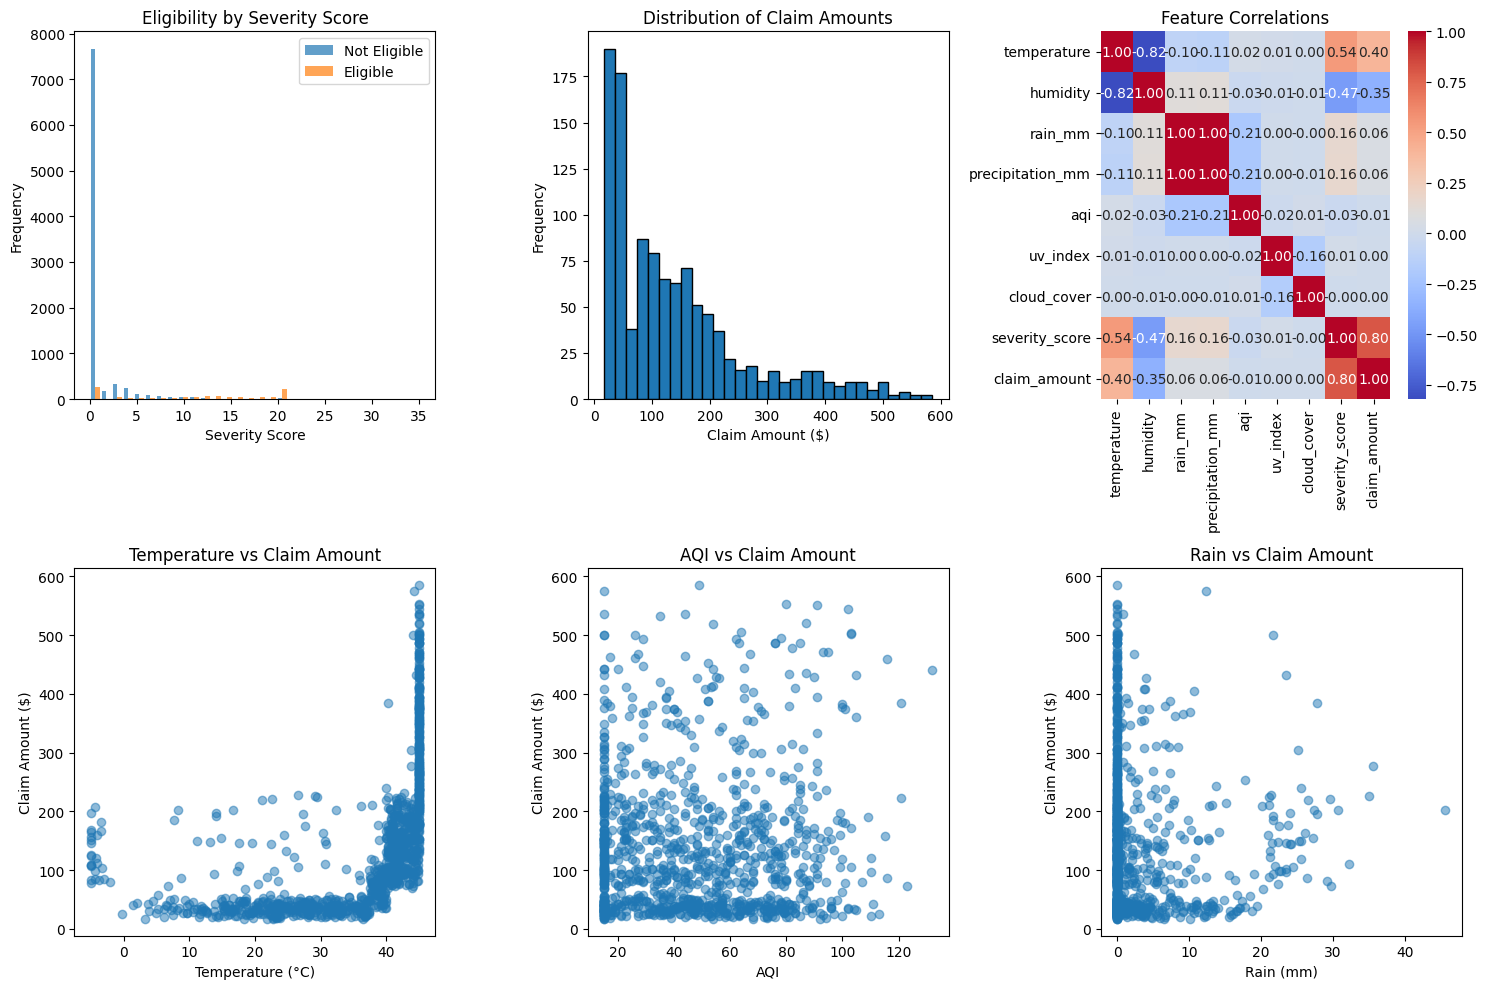


MODELS SAVED SUCCESSFULLY!
Files saved:
  - insurance_classifier.pkl (eligibility prediction)
  - claim_amount_regressor.pkl (amount prediction)
  - classifier_scaler.pkl
  - regressor_scaler.pkl

EXAMPLE PREDICTION:
Weather conditions: {'temperature': 38.5, 'humidity': 85.0, 'rain_mm': 25.0, 'precipitation_mm': 25.0, 'aqi': 180, 'uv_index': 9.5, 'cloud_cover': 90.0}
Eligible for insurance: True
Eligibility probability: 56.00%
Predicted claim amount: $133.88


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('gig_worker_insurance_data.csv')

features = ['temperature', 'humidity', 'rain_mm', 'precipitation_mm', 'aqi', 'uv_index', 'cloud_cover']
X = df[features]
y_class = df['insurance_applicable']

X_train, X_test, y_train, y_test = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

print("="*60)
print("CLASSIFICATION RESULTS - Predicting Insurance Eligibility")
print("="*60)

best_model = None
best_score = 0

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    auc = roc_auc_score(y_test, y_pred_proba)
    
    if auc > best_score:
        best_score = auc
        best_model = model

if hasattr(best_model, 'feature_importances_'):
    importance = best_model.feature_importances_
    feature_importance = pd.DataFrame({
        'feature': features,
        'importance': importance
    }).sort_values('importance', ascending=False)
    
eligible_df = df[df['insurance_applicable'] == 1].copy()
X_reg = eligible_df[features]
y_reg = eligible_df['claim_amount']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)


from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

reg_models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

best_reg_model = None
best_reg_score = -np.inf

for name, model in reg_models.items():
    model.fit(X_train_reg_scaled, y_train_reg)
    y_pred_reg = model.predict(X_test_reg_scaled)
    
    mae = mean_absolute_error(y_test_reg, y_pred_reg)
    r2 = r2_score(y_test_reg, y_pred_reg)
    
    print(f"\n{name}:")
    print(f"  MAE: ${mae:.2f}")
    print(f"  R² Score: {r2:.3f}")
    
    if r2 > best_reg_score:
        best_reg_score = r2
        best_reg_model = model


import joblib

joblib.dump(best_model, 'insurance_classifier.pkl')
joblib.dump(best_reg_model, 'claim_amount_regressor.pkl')
joblib.dump(scaler, 'classifier_scaler.pkl')
joblib.dump(scaler_reg, 'regressor_scaler.pkl')



def predict_insurance_payout(weather_data):
    clf = joblib.load('insurance_classifier.pkl')
    reg = joblib.load('claim_amount_regressor.pkl')
    scaler_clf = joblib.load('classifier_scaler.pkl')
    scaler_reg = joblib.load('regressor_scaler.pkl')
    
    input_df = pd.DataFrame([weather_data])
    
    input_scaled_clf = scaler_clf.transform(input_df[features])
    
    eligible_prob = clf.predict_proba(input_scaled_clf)[0, 1]
    eligible = clf.predict(input_scaled_clf)[0]
    
    result = {
        'eligible': bool(eligible),
        'eligibility_probability': float(eligible_prob),
        'claim_amount': 0.0
    }
    
    if eligible:
        input_scaled_reg = scaler_reg.transform(input_df[features])
        claim_amount = reg.predict(input_scaled_reg)[0]
        result['claim_amount'] = round(float(claim_amount), 2)
    
    return result
